# 使用LLaMA-Factory微调Qwen3-4B-instruct模型

[LLaMA Factory](https://github.com/hiyouga/LLaMA-Factory) 是一款开源低代码大模型微调框架，集成了业界广泛使用的微调技术，支持通过 Web UI 界面零代码微调大模型，目前已经成为开源社区内最受欢迎的微调框架之一，GitHub 星标超过 4.5 万。

Qwen3 是阿里云新一代 Qwen系列模型：
- 1. 支持场景更广泛：推理模式和非推理模式的有效融合，可在对话中根据用户要求，实现两种模式的任意切换
- 2. 推理性能更高效：新增了两个Qwen3-235B-A22B，Qwen3-30B-A3B的MOE模型
- 3. 细分通用能力增强：创意写作、角色扮演、多轮对话、指令遵循能力均有明显提升
- 4. 工具调用更准确：强化了agent能力，实现了更好的工具调用，更好的MCP支持
- 5. 多语言支持更全面：多语言专项增强，可以支持100+语言&方言


本教程以Qwen最新开源的 [Qwen3-4B-Instruct](https://modelscope.cn/models/Qwen/Qwen3-4B) 模型为例，介绍如何使用 PAI 平台及 LLaMA Factory 训练框架微调得到新闻标题分类器：给定新闻的类别范围，通过自然语言触发新闻标题分类的功能，并以特定的格式进行返回。

具体的要求为：
- 给定新闻种类，根据新闻标题对新闻进行分类。
- 输入为新闻标题，输出为新闻所属的种类，不需要额外解释，但保留思维链的内容；在输入的新闻标题前加上“新闻分类：”等类似文本来标明询问目的。

## 运行环境要求

-  GPU   显存：大于等于 12 GB


## 1. 安装LLaMA Factory

首先，拉取LLaMA-Factory项目到DSW实例。

In [1]:
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
fatal: destination path 'LLaMA-Factory' already exists and is not an empty directory.


接着，我们安装LLaMA-Factory依赖环境。

In [4]:
!python3.10 -m pip install --upgrade pip

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.6 MB/s eta 0:00:00a 0:00:01m
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [7]:
%cd LLaMA-Factory
!pip install -e ".[metrics]"

[Errno 2] No such file or directory: 'LLaMA-Factory'
/mnt/workspace/demos/qwen3_4b_llama_factory/LLaMA-Factory
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Obtaining file:///mnt/workspace/demos/qwen3_4b_llama_factory/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llamafactory (pyproject.toml) ... done
  Created wheel for llamafactory: filename=llamafactory-0.9.4.dev0-0.editable-py3-none-any.whl size=28395 sha256=91fbcf1f3c797c95c64880dec42247172cece44d8e37229f3560bde1dca02e63
  Stored in directory: /tmp/pip-ephem-wheel-cache-5_nx4zyk/wheels/bc/39/bb/2b47532d9820fe0186ffd6f9eea879f109de4cfc804610feac
Successfully built llamafactory
  Attempting uninstall: llamafactory
    Found existing installation: llamafactory 0.9.4.dev0
    Uninstalling llamafactory-0.9.4.dev0:
      Successfully uninstalled llamafactory-0.9.4.dev0


发现出现环境冲突，使用 pip install --no-deps -e . 解决

In [3]:
!pip install --no-deps -e .

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Obtaining file:///mnt/workspace/demos/qwen3_4b_llama_factory/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llamafactory (pyproject.toml) ... done
  Created wheel for llamafactory: filename=llamafactory-0.9.4.dev0-0.editable-py3-none-any.whl size=28395 sha256=a889986d8d271aa946b85d61b4521efcff0da23001580a6a75728a047c502dce
  Stored in directory: /tmp/pip-ephem-wheel-cache-fkkzvu_n/wheels/bc/39/bb/2b47532d9820fe0186ffd6f9eea879f109de4cfc804610feac
Successfully built llamafactory

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python3.10 -m pip install --upgrade pip


运行如下命令，如果显示llamafactory-cli的版本，则表示安装成功。

In [8]:
!llamafactory-cli version

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.4.dev0           |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


## 2. 下载数据集

LLaMA-Factory项目内置了丰富的数据集，放在了`data`目录下。您也可以准备自定义数据集，将数据处理为框架特定的格式，放在`data`下，并且修改`dataset_info.json`文件。
本教程准备了一份sharegpt格式的对话数据集，运行下述命令下载数据。

In [7]:
!wget https://atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com/release/llama_factory/data_news_300.zip
!unzip data_news_300.zip

--2025-04-29 13:55:55--  https://atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com/release/llama_factory/data_news_300.zip
正在解析主机 atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com (atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com)... 47.101.88.43
正在连接 atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com (atp-modelzoo-sh.oss-cn-shanghai.aliyuncs.com)|47.101.88.43|:443... 已连接。
已发出 HTTP 请求，正在等待回应... 200 OK
长度： 151242 (148K) [application/zip]
正在保存至: ‘data_news_300.zip’

data_news_300.zip   100%[===================>] 147.70K  --.-KB/s    用时 0.02s   

2025-04-29 13:55:55 (7.04 MB/s) - 已保存 ‘data_news_300.zip’ [151242/151242])

Archive:  data_news_300.zip
  inflating: data_news_300/dataset_info.json  
  inflating: data_news_300/eval.json  
  inflating: data_news_300/train.json  


打印此刻数据集的路径，待会训练要用

In [9]:
!cd data/tianchi6/ && pwd

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/mnt/workspace/demos/qwen3_4b_llama_factory/LLaMA-Factory/data/tianchi6



数据集分为训练集和验证集两个文件，其中训练集包含300组对话样本，是根据新闻分类器的要求准备的：
- 根据新闻标题对新闻进行分类，新闻种类包括：政治、经济、科技、娱乐、体育、教育、健康、国际、国内、社会。
- 输入为新闻标题，输出为新闻所属的种类，不需要额外解释，但保留思维链的内容；在输入的新闻标题前加上“新闻分类：”等类似标签来标明询问目的。

数据样例如下：

```json
[
    {
        "conversations": [
            {
                "from": "human",
                "value": "新闻分类：给力！中国两次出手，美到手的订单黄了，该国从此只认中国制造！"
            },
            {
                "from": "gpt",
                "value": "<think>\n首先，我需要分析给出的新闻标题：“给力！中国两次出手，美到手的订单黄了，该国从此只认中国制造！”\n\n接下来，根据标题内容进行分类。标题中提到了中国两次行动导致美国订单出现问题，并且其他国家开始依赖中国制造，说明这涉及国家之间的经济合作和社会影响。\n\n结合新闻种类，考虑到涉及国际贸易和经济合作，最合适的分类是“经济”。所以，这条新闻应该归类到“经济”类别中。\n</think>\n\n经济"
            }
        ]
    },
    {
        "conversations": [
            {
                "from": "human",
                "value": "新闻分类：澳大利亚旅游"
            },
            {
                "from": "gpt",
                "value": "<think>\n好吧，我现在要分析这条新闻标题“澳大利亚旅游”属于哪个类别。首先，标题提到的是澳大利亚旅游，所以它和旅游相关。接下来，我需要看看新闻种类里有没有相关的类别。新闻种类包括政治、经济、科技、娱乐、体育、教育、健康、国际、国内、社会，以及旅游。\n\n根据知识储备，旅游本身就属于其中一个类别，可能属于社会或娱乐，但通常旅游更具体，可能单独作为一个类别。不过在这份分类中，并没有独自一个旅游的类别，可能需要看看有没有更合适的。比如，如果列举的是旅游，可能属于社会，因为旅游涉及到人们的生活方式和社会活动。\n\n再想一下，可能“旅游”不太明显属于哪一个大类，可能需要归类到社会中。或者，在给定的选项中，可能没有明确的旅游类别，所以可能需要根据其他因素来判断。假设在预定义的分类中，有旅游作为独立类别的话，那就是旅游；如果没有，就放到社会里。\n\n不过根据用户提供的分类，旅游并没有单独作为一个类，所以可能得归类到社会。或者，可能更接近于“国际”或“国内”，因为澳大利亚可能分为国际或国内旅游。但在这份列表里，国际和国内是两个类别，所以“澳大利亚旅游”作为国内的，可能更准确。\n\n再仔细分析，用户提供的新闻类型是国际、国内，所以如果是国内，应该是国内旅游；如果是跨国，比如其他国家的旅游，那就是国际。所以“澳大利亚旅游”属于国内，因为澳大利亚是中国的国内。所以最终归类到“国内”。\n</think>\n\n国内"
            }
        ]
    }
]

```

## 3. 启动微调任务

#### 3.1.启动LLaMA Board
确认 LLaMA Factory 安装完成后，运行以下指令启动 LLaMA Board。
这里用到的环境变量解释如下：

- `USE_MODELSCOPE_HUB`设为1，表示模型来源是ModelScope。使用HuggingFace模型可能会有网络问题。
- `CUDA_VISIBLE_DEVICES`：指定使用的显卡序号，默认全部使用

In [1]:
!export USE_MODELSCOPE_HUB=1 CUDA_VISIBLE_DEVICES=0 && llamafactory-cli webui

'export' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


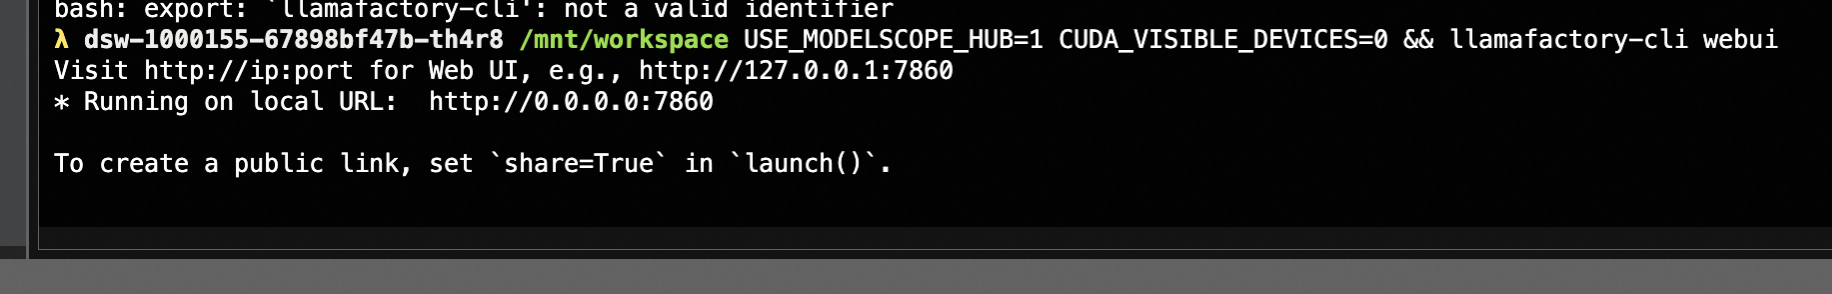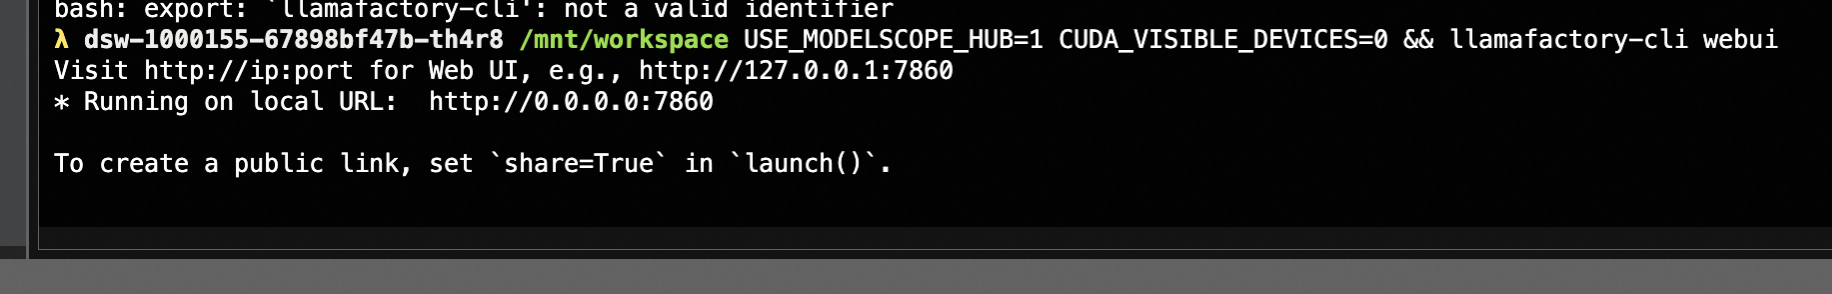点击返回的URL地址，进入Web UI页面。
![t-a-1](./images/t-a-1.png)

#### 3.2.选择Qwen3-4B-Instruct模型
进入Web UI界面后，选择模型为Qwen3-4B-Instruct模型，模型路径可填写本地绝对路径，不填则从互联网下载
![t-a-2](./images/t-a-2.png)

#### 3.3.选择微调数据集
将数据路径改为使用我们上述打印的数据路径，选择train、eval数据。
![t-a-3](./images/t-a-3.png)

#### 3.4.配置微调参数
为了让模型更好地学习数据知识，将学习率改为 1e-4，训练轮数提高到 8 轮。批处理大小和梯度累计则根据设备显存大小调整，在显存允许的情况下提高批处理大小有助于加速训练，一般保持批处理大小×梯度累积×显卡数量等于 32 即可。
![t-a-4](./images/t-a-4.png)

#### 3.5.其他参数配置
点击其他参数设置，将保存间隔设置为 50，保存更多的检查点，有助于观察模型效果随训练轮数的变化。
![t-a-5](./images/t-a-5.png)

#### 3.6.LoRA参数设置	
点击 LoRA 参数设置，将 LoRA 秩设置为 16，并把 LoRA 缩放系数设置为 32。
![t-a-6](./images/t-a-6.png)

#### 3.7.开始训练
点击开始按钮，等待模型下载，一段时间后应能观察到训练过程的损失曲线。
![t-a-7](./images/t-a-7.png)

#### 3.8.训练完成
等待模型训练完毕，视显卡性能，训练时间可能在 20-60 分钟不等。
![t-a-8](./images/t-a-8.png)


## 4. 验证微调效果

4.1. 选择检查点路径为刚才的输出目录，打开 Chat 页面，点击加载模型
![p-1](./images/p-2.png)

4.2.  在页面底部的对话框输入想要和模型对话的内容，点击「提交」即可发送消息

发送后模型会逐字生成回答，从回答中可以发现模型学习到了数据集中的内容，能够识别出用户是想对后面的标题进行新闻分类，且满足要求的输出格式，直接输出新闻分类，没有额外解释。

![image.png](./images/t-1.png)
![image.png](./images/t-2.png)

把前缀“新闻分类”改成类似的表达去询问，发现仍能满足要求。
![image.png](./images/t-3.png)

清空历史后（避免上下文的影响），问模型其他的问题，发现其仍能正常回答，没有过拟合。
![image.png](./images/t-4.png)
